# VQ-VAE Diagnostic Notebook: Toy Dataset Experiments

This notebook systematically diagnoses VQ-VAE issues by testing the architecture on synthetic datasets with known ground truth structure.

**Experiments:**
1. Architecture Capacity Test (can encoder/decoder learn without VQ?)
2. VQ Layer Behavior Test (does codebook learn meaningful clusters?)
3. Variable-Length Handling Test (does masking work correctly?)
4. Feature Scaling Ablation (does asymmetric scaling cause issues?)
5. Progressive Difficulty Test (at what complexity does the model fail?)

## Setup & Imports

In [1]:
%matplotlib inline

import os
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

### visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

### dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

### progress tracking
from tqdm.auto import tqdm

### particlemind imports
from particlemind.models.vqvae import VQVAENormFormer, VQVAEMLP, NormformerStack
from vqtorch.nn import VectorQuant

### plot settings
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rc('font', size=12)

### set device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

### output directory
OUTPUT_DIR = Path('./plots/diagnostics')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/global/cfs/cdirs/m3246/mpettee/hep/particlemind/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/cfs/cdirs/m3246/mpettee/hep/particlemind/.venv/lib64/python3.11/site-packages/stringcolor/main.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [2]:
### reproducibility
def set_seed(seed=42):
    """Ensure reproducible results."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

---
## Section 1: Toy Dataset Generators

In [3]:
### =====================================================
### Level 1: Simple Fixed-Length 4D Gaussian Blobs
### =====================================================

def generate_gaussian_blobs(n_samples=10000, n_clusters=8, dim=4, cluster_std=0.3, seed=42):
    """
    Generate 4D data with clear cluster structure.
    Ground truth: cluster assignments are known.
    Expected: VQ codebook should learn ~n_clusters distinct codes.
    """
    X, y = make_blobs(
        n_samples=n_samples, 
        n_features=dim, 
        centers=n_clusters, 
        cluster_std=cluster_std, 
        random_state=seed
    )
    ### normalize to similar scale
    X = X / X.std(axis=0)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y)


### test
X_blobs, y_blobs = generate_gaussian_blobs(n_samples=5000, n_clusters=8)
print(f"Gaussian blobs shape: {X_blobs.shape}")
print(f"Feature means: {X_blobs.mean(dim=0).numpy()}")
print(f"Feature stds:  {X_blobs.std(dim=0).numpy()}")
print(f"Number of clusters: {len(torch.unique(y_blobs))}")

Gaussian blobs shape: torch.Size([5000, 4])
Feature means: [-0.04270056 -0.18402296 -0.770694   -0.01662959]
Feature stds:  [1.0001 1.0001 1.0001 1.0001]
Number of clusters: 8


In [4]:
### =====================================================
### Level 2: Variable-Length Sequences
### =====================================================

def generate_variable_length_blobs(n_events=1000, min_len=20, max_len=200, 
                                    n_clusters=8, dim=4, seed=42):
    """
    Generate events with variable number of hits from cluster distribution.
    Mimics the variable-length nature of calorimeter events.
    """
    np.random.seed(seed)
    
    ### create cluster centers
    cluster_centers = np.random.randn(n_clusters, dim) * 2
    
    events = []
    masks = []
    labels = []
    max_seq_len = max_len
    
    for _ in range(n_events):
        seq_len = np.random.randint(min_len, max_len)
        ### sample from clusters
        cluster_ids = np.random.randint(0, n_clusters, seq_len)
        centers = cluster_centers[cluster_ids]
        hits = centers + np.random.randn(seq_len, dim) * 0.3
        
        ### pad to max length
        padded = np.zeros((max_seq_len, dim))
        padded[:seq_len] = hits
        mask = np.zeros(max_seq_len)
        mask[:seq_len] = 1
        
        events.append(padded)
        masks.append(mask)
        labels.append(cluster_ids)
    
    return {
        'features': torch.tensor(np.array(events), dtype=torch.float32),
        'masks': torch.tensor(np.array(masks), dtype=torch.float32),
        'labels': labels
    }


### test
var_len_data = generate_variable_length_blobs(n_events=100, min_len=20, max_len=100)
print(f"Variable-length features shape: {var_len_data['features'].shape}")
print(f"Masks shape: {var_len_data['masks'].shape}")
print(f"Sequence lengths: min={var_len_data['masks'].sum(dim=1).min():.0f}, "
      f"max={var_len_data['masks'].sum(dim=1).max():.0f}, "
      f"mean={var_len_data['masks'].sum(dim=1).mean():.1f}")

Variable-length features shape: torch.Size([100, 100, 4])
Masks shape: torch.Size([100, 100])
Sequence lengths: min=20, max=99, mean=58.4


In [5]:
### =====================================================
### Level 3: Synthetic Calorimeter-Like Data
### =====================================================

def generate_synthetic_calorimeter(n_events=500, min_hits=50, max_hits=300, seed=42):
    """
    Generate synthetic data mimicking calorimeter hit distributions:
    - Positions follow cylindrical geometry
    - Energy follows approximate power-law distribution
    - Hits cluster around "shower" directions
    
    Feature scaling matches real data: positions scaled, energy scaled
    """
    np.random.seed(seed)
    
    events = []
    masks = []
    max_len = max_hits
    
    for _ in range(n_events):
        n_hits = np.random.randint(min_hits, max_hits)
        
        ### generate 2-4 "showers" per event
        n_showers = np.random.randint(2, 5)
        shower_centers = []
        for _ in range(n_showers):
            theta = np.random.uniform(0.2, np.pi - 0.2)
            phi = np.random.uniform(0, 2 * np.pi)
            r = np.random.uniform(1.5, 4.0)  ### radial distance (scaled like real)
            shower_centers.append([
                r * np.sin(theta) * np.cos(phi),
                r * np.sin(theta) * np.sin(phi),
                r * np.cos(theta)
            ])
        
        hits = []
        for _ in range(n_hits):
            ### pick a random shower
            center = shower_centers[np.random.randint(n_showers)]
            ### add hit near shower center with spread
            x = center[0] + np.random.normal(0, 0.3)
            y = center[1] + np.random.normal(0, 0.3)
            z = center[2] + np.random.normal(0, 0.5)
            ### energy: power-law with occasional high-energy hits
            energy = np.random.exponential(0.5) * 100  ### scaled like real data
            hits.append([x, y, z, energy])
        
        ### pad and store
        padded = np.zeros((max_len, 4))
        padded[:n_hits] = np.array(hits)
        mask = np.zeros(max_len)
        mask[:n_hits] = 1
        
        events.append(padded)
        masks.append(mask)
    
    return {
        'features': torch.tensor(np.array(events), dtype=torch.float32),
        'masks': torch.tensor(np.array(masks), dtype=torch.float32)
    }


### test
calo_data = generate_synthetic_calorimeter(n_events=50)
print(f"Synthetic calo features shape: {calo_data['features'].shape}")
valid_hits = calo_data['features'][calo_data['masks'] == 1]
print(f"Feature stats (valid hits only):")
print(f"  x: mean={valid_hits[:, 0].mean():.2f}, std={valid_hits[:, 0].std():.2f}")
print(f"  y: mean={valid_hits[:, 1].mean():.2f}, std={valid_hits[:, 1].std():.2f}")
print(f"  z: mean={valid_hits[:, 2].mean():.2f}, std={valid_hits[:, 2].std():.2f}")
print(f"  E: mean={valid_hits[:, 3].mean():.2f}, std={valid_hits[:, 3].std():.2f}")

Synthetic calo features shape: torch.Size([50, 300, 4])
Feature stats (valid hits only):
  x: mean=0.11, std=1.39
  y: mean=-0.04, std=1.51
  z: mean=0.00, std=1.82
  E: mean=50.54, std=50.62


In [6]:
### =====================================================
### Level 4: Feature Scaling Comparison
### =====================================================

def generate_asymmetric_scaled_data(n_samples=10000, seed=42):
    """
    Generate data with asymmetric scaling like the real data:
    Position features: O(1) scale (like pos/1000)
    Energy feature: O(10-100) scale (like energy*100)
    """
    np.random.seed(seed)
    ### positions: small scale
    positions = np.random.uniform(-3, 3, (n_samples, 3))
    ### energy: large scale, exponential
    energy = np.random.exponential(10, (n_samples, 1)) * 10
    X = np.hstack([positions, energy])
    return torch.tensor(X, dtype=torch.float32)


def generate_normalized_data(n_samples=10000, seed=42):
    """
    Same underlying distribution but properly z-score normalized.
    All features zero-mean, unit variance.
    """
    np.random.seed(seed)
    positions = np.random.uniform(-3, 3, (n_samples, 3))
    energy = np.random.exponential(10, (n_samples, 1))
    X = np.hstack([positions, energy])
    ### standardize each feature
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return torch.tensor(X, dtype=torch.float32)


### test
X_asym = generate_asymmetric_scaled_data(5000)
X_norm = generate_normalized_data(5000)

print("Asymmetric scaling (like real data):")
print(f"  Feature stds: {X_asym.std(dim=0).numpy()}")
print(f"  Scale ratio (energy/positions): {X_asym[:, 3].std() / X_asym[:, :3].std():.1f}x")

print("\nNormalized scaling:")
print(f"  Feature stds: {X_norm.std(dim=0).numpy()}")

Asymmetric scaling (like real data):
  Feature stds: [  1.7185639   1.7369186   1.7401619 102.50027  ]
  Scale ratio (energy/positions): 59.2x

Normalized scaling:
  Feature stds: [1.0001 1.0001 1.0001 1.0001]


### Visualize All Datasets

Compare the structure and feature distributions of each toy dataset.

DATASET VISUALIZATIONS

L1: Gaussian Blobs (8 clusters, normalized)


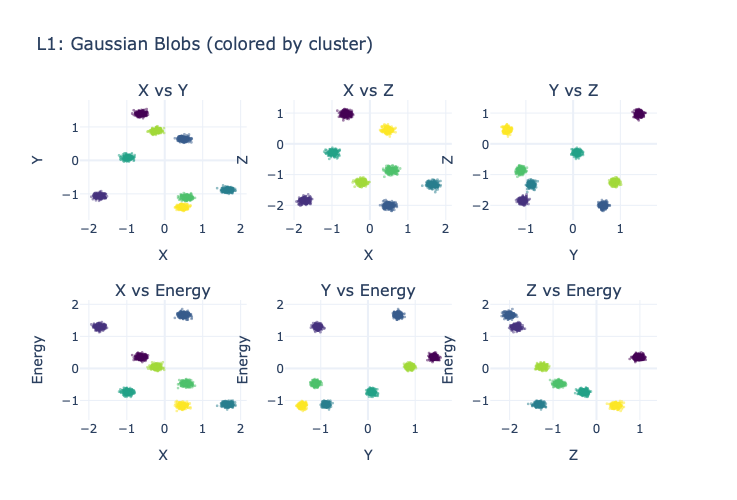


L2: Variable-Length Sequences (showing first event)


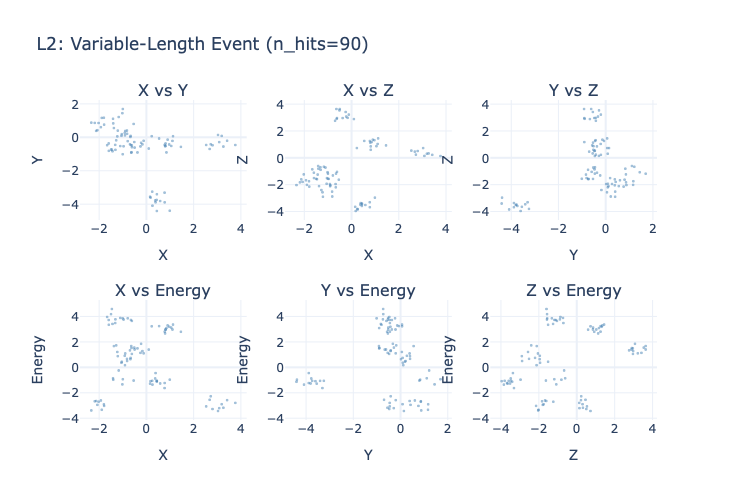


L3: Synthetic Calorimeter (asymmetric scaling)


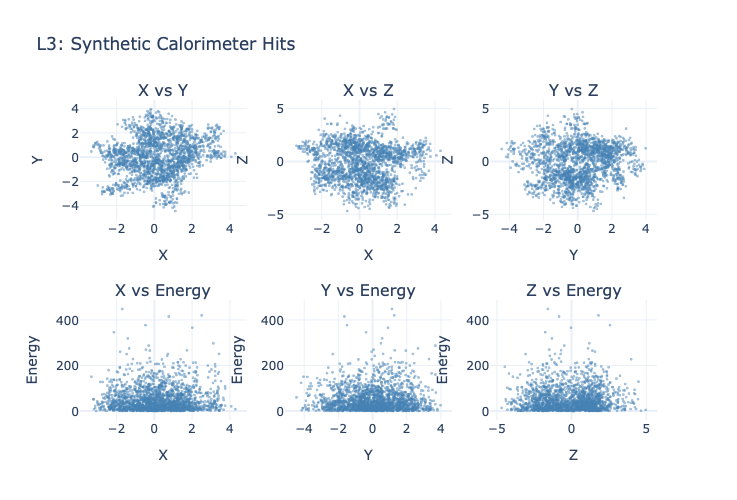


L4: Feature Scaling Comparison


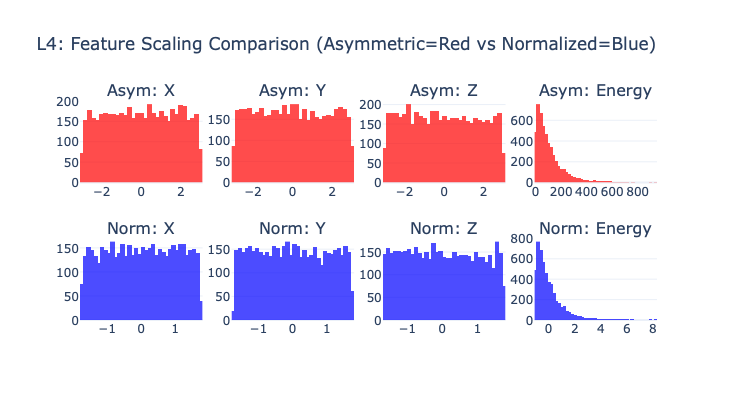


Note the ~60x scale difference in energy between asymmetric and normalized!


In [7]:
### =====================================================
### Visualize All Toy Datasets
### =====================================================

def plot_dataset_4d(X, title, labels=None, sample_size=2000):
    """Plot 4D dataset using scatter matrix and 3D projections."""
    if len(X) > sample_size:
        idx = np.random.choice(len(X), sample_size, replace=False)
        X = X[idx]
        if labels is not None:
            labels = labels[idx]
    
    X_np = X.numpy() if torch.is_tensor(X) else X
    
    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=['X vs Y', 'X vs Z', 'Y vs Z', 'X vs Energy', 'Y vs Energy', 'Z vs Energy'],
        specs=[[{'type': 'scatter'}, {'type': 'scatter'}, {'type': 'scatter'}],
               [{'type': 'scatter'}, {'type': 'scatter'}, {'type': 'scatter'}]]
    )
    
    color = labels.numpy() if labels is not None else 'steelblue'
    colorscale = 'Viridis' if labels is not None else None
    
    pairs = [(0, 1), (0, 2), (1, 2), (0, 3), (1, 3), (2, 3)]
    feat_names = ['X', 'Y', 'Z', 'Energy']
    
    for i, (f1, f2) in enumerate(pairs):
        row, col = i // 3 + 1, i % 3 + 1
        fig.add_trace(
            go.Scatter(
                x=X_np[:, f1], y=X_np[:, f2],
                mode='markers',
                marker=dict(size=3, opacity=0.5, color=color, colorscale=colorscale),
                showlegend=False
            ),
            row=row, col=col
        )
        fig.update_xaxes(title_text=feat_names[f1], row=row, col=col)
        fig.update_yaxes(title_text=feat_names[f2], row=row, col=col)
    
    fig.update_layout(title=title, height=500, width=900, template='plotly_white')
    return fig


print("="*60)
print("DATASET VISUALIZATIONS")
print("="*60)

### L1: Gaussian Blobs
print("\nL1: Gaussian Blobs (8 clusters, normalized)")
fig_l1 = plot_dataset_4d(X_blobs, "L1: Gaussian Blobs (colored by cluster)", y_blobs)
fig_l1.show()

### L2: Variable-Length (show one event's hits)
print("\nL2: Variable-Length Sequences (showing first event)")
event_0 = var_len_data['features'][0]
mask_0 = var_len_data['masks'][0]
valid_hits = event_0[mask_0 == 1]
fig_l2 = plot_dataset_4d(valid_hits, f"L2: Variable-Length Event (n_hits={int(mask_0.sum())})")
fig_l2.show()

### L3: Synthetic Calorimeter
print("\nL3: Synthetic Calorimeter (asymmetric scaling)")
calo_valid = calo_data['features'][calo_data['masks'] == 1]
fig_l3 = plot_dataset_4d(calo_valid[:5000], "L3: Synthetic Calorimeter Hits")
fig_l3.show()

### L4: Compare Asymmetric vs Normalized scaling
print("\nL4: Feature Scaling Comparison")
fig_l4 = make_subplots(
    rows=2, cols=4,
    subplot_titles=[
        'Asym: X', 'Asym: Y', 'Asym: Z', 'Asym: Energy',
        'Norm: X', 'Norm: Y', 'Norm: Z', 'Norm: Energy'
    ]
)

for i in range(4):
    fig_l4.add_trace(
        go.Histogram(x=X_asym[:, i].numpy(), nbinsx=50, marker_color='red', opacity=0.7, showlegend=False),
        row=1, col=i+1
    )
    fig_l4.add_trace(
        go.Histogram(x=X_norm[:, i].numpy(), nbinsx=50, marker_color='blue', opacity=0.7, showlegend=False),
        row=2, col=i+1
    )

fig_l4.update_layout(
    title="L4: Feature Scaling Comparison (Asymmetric=Red vs Normalized=Blue)",
    height=400, width=1000, template='plotly_white'
)
fig_l4.show()

print("\nNote the ~60x scale difference in energy between asymmetric and normalized!")

---
## Section 2: Model Variants for Ablation

In [8]:
### =====================================================
### Variant A: Simple MLP Autoencoder (Baseline)
### =====================================================

class SimpleMLPAutoencoder(nn.Module):
    """
    Minimal MLP autoencoder without attention or VQ.
    Tests if basic reconstruction is achievable.
    """
    def __init__(self, input_dim=4, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
        self.latent_dim = latent_dim
    
    def forward(self, x, mask=None):
        z = self.encoder(x)
        x_reco = self.decoder(z)
        if mask is not None:
            x_reco = x_reco * mask.unsqueeze(-1)
        return x_reco, {'z': z, 'loss': torch.tensor(0.0, device=x.device)}


### test
mlp_ae = SimpleMLPAutoencoder(input_dim=4, hidden_dim=64, latent_dim=16)
test_x = torch.randn(32, 4)
out, vq_out = mlp_ae(test_x)
print(f"MLP AE: input {test_x.shape} -> output {out.shape}, latent {vq_out['z'].shape}")

MLP AE: input torch.Size([32, 4]) -> output torch.Size([32, 4]), latent torch.Size([32, 16])


In [9]:
### =====================================================
### Variant B: NormFormer Autoencoder (No VQ)
### =====================================================

class AutoencoderNormFormer(nn.Module):
    """
    NormFormer-based autoencoder WITHOUT vector quantization.
    Tests if the transformer architecture can learn reconstructions.
    """
    def __init__(self, input_dim=4, latent_dim=16, hidden_dim=64, 
                 num_heads=2, num_blocks=2, dropout=0.1):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.encoder = NormformerStack(
            hidden_dim=hidden_dim, 
            num_heads=num_heads, 
            num_blocks=num_blocks,
            # dropout=dropout
        )
        self.latent_in = nn.Linear(hidden_dim, latent_dim)
        self.latent_out = nn.Linear(latent_dim, hidden_dim)
        self.decoder = NormformerStack(
            hidden_dim=hidden_dim, 
            num_heads=num_heads, 
            num_blocks=num_blocks,
            # dropout=dropout
        )
        self.output_projection = nn.Linear(hidden_dim, input_dim)
    
    def forward(self, x, mask=None):
        ### create default mask of all 1s if none provided
        ### NormformerStack requires a valid mask
        if mask is None:
            mask = torch.ones(x.shape[0], x.shape[1], device=x.device)
        
        ### encode
        h = self.input_projection(x)
        h = self.encoder(h, mask=mask)
        z = self.latent_in(h)
        z = z * mask.unsqueeze(-1)
        
        ### decode (no VQ - direct passthrough)
        h_out = self.latent_out(z)
        h_out = h_out * mask.unsqueeze(-1)
        h_out = self.decoder(h_out, mask=mask)
        x_reco = self.output_projection(h_out)
        x_reco = x_reco * mask.unsqueeze(-1)
        
        return x_reco, {'z': z, 'loss': torch.tensor(0.0, device=x.device)}


### test
nf_ae = AutoencoderNormFormer(input_dim=4, latent_dim=16, hidden_dim=64)
test_x = torch.randn(8, 50, 4)  ### (batch, seq_len, features)
test_mask = torch.ones(8, 50)
out, vq_out = nf_ae(test_x, test_mask)
print(f"NormFormer AE: input {test_x.shape} -> output {out.shape}, latent {vq_out['z'].shape}")

### also test without mask (should create default)
out2, _ = nf_ae(test_x, None)
print(f"NormFormer AE (no mask): input {test_x.shape} -> output {out2.shape}")

NormFormer AE: input torch.Size([8, 50, 4]) -> output torch.Size([8, 50, 4]), latent torch.Size([8, 50, 16])
NormFormer AE (no mask): input torch.Size([8, 50, 4]) -> output torch.Size([8, 50, 4])


In [10]:
### =====================================================
### VQ Configuration Variants
### =====================================================

VQ_CONFIGS = {
    'default': {
        'num_codes': 512,
        'beta': 0.9,
        'kmeans_init': False,
        'affine_lr': 0.0,
        'sync_nu': 2,
        'replace_freq': 20,
        'dim': -1
    },
    'fewer_codes': {
        'num_codes': 64,
        'beta': 0.9,
        'kmeans_init': False,
        'affine_lr': 0.0,
        'sync_nu': 2,
        'replace_freq': 20,
        'dim': -1
    },
    'kmeans_init': {
        'num_codes': 512,
        'beta': 0.9,
        'kmeans_init': True,
        'affine_lr': 0.0,
        'sync_nu': 2,
        'replace_freq': 20,
        'dim': -1
    },
    'low_commitment': {
        'num_codes': 512,
        'beta': 0.5,
        'kmeans_init': False,
        'affine_lr': 0.0,
        'sync_nu': 2,
        'replace_freq': 20,
        'dim': -1
    },
}

print("Available VQ configurations:")
for name, config in VQ_CONFIGS.items():
    print(f"  {name}: {config['num_codes']} codes, beta={config['beta']}, kmeans={config['kmeans_init']}")

Available VQ configurations:
  default: 512 codes, beta=0.9, kmeans=False
  fewer_codes: 64 codes, beta=0.9, kmeans=False
  kmeans_init: 512 codes, beta=0.9, kmeans=True
  low_commitment: 512 codes, beta=0.5, kmeans=False


---
## Section 3: Training Infrastructure

In [11]:
def train_model(model, dataloader, n_epochs=20, lr=1e-3, alpha=5.0, 
                device=DEVICE, verbose=True, use_mask=False):
    """
    Lightweight training loop for diagnostic experiments.
    
    Args:
        model: model to train
        dataloader: training data
        n_epochs: number of epochs
        lr: learning rate
        alpha: VQ commitment loss weight
        device: torch device
        verbose: print progress
        use_mask: whether data has explicit masks (for variable-length sequences)
    
    Returns:
        dict: training history
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    history = {
        'train_loss': [],
        'reco_loss': [],
        'vq_loss': [],
        'codebook_usage': [],
    }
    
    for epoch in range(n_epochs):
        model.train()
        epoch_losses = {'total': [], 'reco': [], 'vq': []}
        all_codes = []
        
        for batch in dataloader:
            if use_mask:
                x = batch['features'].to(device)
                mask = batch['masks'].to(device)
            else:
                if isinstance(batch, (list, tuple)):
                    x = batch[0].to(device)
                else:
                    x = batch.to(device)
                ### create default mask of all 1s for models that require it
                ### (VQVAENormFormer and NormformerStack require valid masks)
                if x.dim() == 3:
                    mask = torch.ones(x.shape[0], x.shape[1], device=device)
                else:
                    mask = None
            
            optimizer.zero_grad()
            x_reco, vq_out = model(x, mask)
            
            ### compute loss
            if mask is not None:
                ### masked MSE loss
                reco_loss = ((x_reco - x) ** 2 * mask.unsqueeze(-1)).sum() / mask.sum()
            else:
                reco_loss = ((x_reco - x) ** 2).mean()
            
            vq_loss = vq_out.get('loss', torch.tensor(0.0, device=device))
            if not torch.is_tensor(vq_loss):
                vq_loss = torch.tensor(vq_loss, device=device)
            
            loss = reco_loss + alpha * vq_loss
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_losses['total'].append(loss.item())
            epoch_losses['reco'].append(reco_loss.item())
            epoch_losses['vq'].append(vq_loss.item())
            
            ### collect codes for usage stats
            if 'q' in vq_out:
                if mask is not None:
                    codes = vq_out['q'][mask == 1].cpu().numpy()
                else:
                    codes = vq_out['q'].cpu().numpy()
                all_codes.extend(codes.flatten())
        
        scheduler.step()
        
        ### record epoch stats
        history['train_loss'].append(np.mean(epoch_losses['total']))
        history['reco_loss'].append(np.mean(epoch_losses['reco']))
        history['vq_loss'].append(np.mean(epoch_losses['vq']))
        
        ### codebook usage
        if all_codes and hasattr(model, 'vqlayer'):
            num_codes = model.vqlayer.codebook.weight.shape[0]
            usage = len(np.unique(all_codes)) / num_codes * 100
            history['codebook_usage'].append(usage)
        else:
            history['codebook_usage'].append(0)
        
        if verbose and (epoch + 1) % 5 == 0:
            usage_str = f", usage={history['codebook_usage'][-1]:.1f}%" if history['codebook_usage'][-1] > 0 else ""
            print(f"Epoch {epoch+1:3d}/{n_epochs}: loss={history['train_loss'][-1]:.6f}, "
                  f"reco={history['reco_loss'][-1]:.6f}, vq={history['vq_loss'][-1]:.6f}{usage_str}")
    
    return history

In [12]:
def compute_entropy(codes, num_codes):
    """Compute normalized entropy of code distribution."""
    codes = np.array(codes).astype(int)
    counts = np.bincount(codes.flatten(), minlength=num_codes)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(num_codes)
    return entropy / max_entropy


def evaluate_model(model, dataloader, device=DEVICE, use_mask=False):
    """
    Evaluate model and compute detailed metrics.
    
    Returns:
        dict: evaluation metrics including MSE, codebook stats, embeddings
    """
    model.eval()
    
    all_x_orig = []
    all_x_reco = []
    all_z = []
    all_z_q = []
    all_codes = []
    
    with torch.no_grad():
        for batch in dataloader:
            if use_mask:
                x = batch['features'].to(device)
                mask = batch['masks'].to(device)
            else:
                if isinstance(batch, (list, tuple)):
                    x = batch[0].to(device)
                else:
                    x = batch.to(device)
                mask = None
            
            x_reco, vq_out = model(x, mask)
            
            if mask is not None:
                valid = mask == 1
                all_x_orig.append(x[valid].cpu().numpy())
                all_x_reco.append(x_reco[valid].cpu().numpy())
                if 'z' in vq_out:
                    all_z.append(vq_out['z'][valid].cpu().numpy())
                if 'z_q' in vq_out:
                    all_z_q.append(vq_out['z_q'][valid].cpu().numpy())
                if 'q' in vq_out:
                    all_codes.extend(vq_out['q'][valid].cpu().numpy().flatten())
            else:
                all_x_orig.append(x.cpu().numpy().reshape(-1, x.shape[-1]))
                all_x_reco.append(x_reco.cpu().numpy().reshape(-1, x_reco.shape[-1]))
                if 'z' in vq_out:
                    all_z.append(vq_out['z'].cpu().numpy().reshape(-1, vq_out['z'].shape[-1]))
                if 'z_q' in vq_out:
                    all_z_q.append(vq_out['z_q'].cpu().numpy().reshape(-1, vq_out['z_q'].shape[-1]))
                if 'q' in vq_out:
                    all_codes.extend(vq_out['q'].cpu().numpy().flatten())
    
    x_orig = np.vstack(all_x_orig)
    x_reco = np.vstack(all_x_reco)
    
    metrics = {
        'overall_mse': np.mean((x_orig - x_reco) ** 2),
        'per_feature_mse': [np.mean((x_orig[:, i] - x_reco[:, i]) ** 2) for i in range(x_orig.shape[1])],
        'x_orig': x_orig,
        'x_reco': x_reco,
    }
    
    if all_z:
        metrics['z'] = np.vstack(all_z)
    if all_z_q:
        metrics['z_q'] = np.vstack(all_z_q)
    if all_codes and hasattr(model, 'vqlayer'):
        num_codes = model.vqlayer.codebook.weight.shape[0]
        codes = np.array(all_codes)
        metrics['codes'] = codes
        metrics['codebook_usage'] = len(np.unique(codes)) / num_codes * 100
        metrics['entropy'] = compute_entropy(codes, num_codes)
        metrics['codebook'] = model.vqlayer.codebook.weight.detach().cpu().numpy()
    
    return metrics

In [13]:
### =====================================================
### Reconstruction Visualization Helper
### =====================================================

def plot_reconstruction_comparison(x_orig, x_reco, title, feature_names=['X', 'Y', 'Z', 'Energy'], 
                                    sample_size=2000):
    """
    Plot original vs reconstructed features to visualize reconstruction quality.
    
    Creates:
    - Scatter plots of original vs reconstructed for each feature (with diagonal reference)
    - Residual histograms for each feature
    """
    if len(x_orig) > sample_size:
        idx = np.random.choice(len(x_orig), sample_size, replace=False)
        x_orig = x_orig[idx]
        x_reco = x_reco[idx]
    
    n_features = x_orig.shape[-1]
    
    fig = make_subplots(
        rows=2, cols=n_features,
        subplot_titles=[f'{fn}: Orig vs Reco' for fn in feature_names] + 
                       [f'{fn}: Residuals' for fn in feature_names],
        vertical_spacing=0.12
    )
    
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
    
    for i in range(n_features):
        orig = x_orig[:, i] if x_orig.ndim == 2 else x_orig[:, 0, i]
        reco = x_reco[:, i] if x_reco.ndim == 2 else x_reco[:, 0, i]
        
        ### Row 1: scatter plot original vs reconstructed
        fig.add_trace(
            go.Scatter(
                x=orig, y=reco,
                mode='markers',
                marker=dict(size=3, opacity=0.3, color=colors[i % len(colors)]),
                showlegend=False
            ),
            row=1, col=i+1
        )
        
        ### add diagonal reference line
        min_val = min(orig.min(), reco.min())
        max_val = max(orig.max(), reco.max())
        fig.add_trace(
            go.Scatter(
                x=[min_val, max_val], y=[min_val, max_val],
                mode='lines',
                line=dict(color='red', dash='dash', width=2),
                showlegend=False
            ),
            row=1, col=i+1
        )
        
        ### Row 2: residual histogram
        residuals = reco - orig
        fig.add_trace(
            go.Histogram(
                x=residuals,
                nbinsx=50,
                marker_color=colors[i % len(colors)],
                opacity=0.7,
                showlegend=False
            ),
            row=2, col=i+1
        )
        
        ### add mean/std annotation
        fig.add_annotation(
            text=f"mean={residuals.mean():.4f}<br>std={residuals.std():.4f}",
            xref=f"x{n_features+i+1} domain", yref=f"y{n_features+i+1} domain",
            x=0.95, y=0.95, showarrow=False, font=dict(size=9),
            bgcolor="white", bordercolor="gray", borderwidth=1
        )
        
        fig.update_xaxes(title_text="Original", row=1, col=i+1)
        fig.update_yaxes(title_text="Reconstructed", row=1, col=i+1)
        fig.update_xaxes(title_text="Residual", row=2, col=i+1)
        fig.update_yaxes(title_text="Count", row=2, col=i+1)
    
    fig.update_layout(
        title=title,
        height=500, width=250*n_features,
        template='plotly_white'
    )
    
    return fig

print("Reconstruction visualization helper defined.")

Reconstruction visualization helper defined.


---
## Section 4: Diagnostic Experiments

### Experiment 1: Architecture Capacity Test

**Goal:** Verify encoder/decoder can learn simple data WITHOUT VQ bottleneck.

**Expected:** MSE < 0.01 on Gaussian blobs for both MLP and NormFormer autoencoders.

In [14]:
print("="*60)
print("EXPERIMENT 1: Architecture Capacity Test")
print("="*60)
print("Testing if encoder/decoder can learn without VQ...\n")

### generate simple data
X_simple, y_simple = generate_gaussian_blobs(n_samples=5000, n_clusters=8, cluster_std=0.3)
simple_loader = DataLoader(TensorDataset(X_simple), batch_size=64, shuffle=True)

exp1_results = {}

### Test MLP Autoencoder
print("Training SimpleMLPAutoencoder...")
set_seed(42)
mlp_ae = SimpleMLPAutoencoder(input_dim=4, hidden_dim=64, latent_dim=16)
mlp_history = train_model(mlp_ae, simple_loader, n_epochs=20, lr=1e-3, alpha=0)
mlp_metrics = evaluate_model(mlp_ae, simple_loader)
exp1_results['MLP_AE'] = {'history': mlp_history, 'metrics': mlp_metrics}
print(f"  Final MSE: {mlp_metrics['overall_mse']:.6f}")
print(f"  Per-feature MSE: {mlp_metrics['per_feature_mse']}\n")

### Test NormFormer Autoencoder (no VQ)
print("Training AutoencoderNormFormer...")
set_seed(42)
### reshape data for sequence model (batch, seq_len=1, features)
X_seq = X_simple.unsqueeze(1)  ### (N, 1, 4)
seq_loader = DataLoader(TensorDataset(X_seq), batch_size=64, shuffle=True)

nf_ae = AutoencoderNormFormer(input_dim=4, latent_dim=16, hidden_dim=64, num_heads=2, num_blocks=2)
nf_history = train_model(nf_ae, seq_loader, n_epochs=20, lr=1e-3, alpha=0)

### evaluate
nf_ae.eval()
with torch.no_grad():
    x_reco, _ = nf_ae(X_seq.to(DEVICE), torch.ones(len(X_seq), 1, device=DEVICE))
    nf_mse = ((x_reco.cpu() - X_seq) ** 2).mean().item()
    per_feat_mse = [((x_reco.cpu()[:, 0, i] - X_seq[:, 0, i]) ** 2).mean().item() for i in range(4)]

exp1_results['NormFormer_AE'] = {
    'history': nf_history, 
    'metrics': {'overall_mse': nf_mse, 'per_feature_mse': per_feat_mse}
}
print(f"  Final MSE: {nf_mse:.6f}")
print(f"  Per-feature MSE: {per_feat_mse}")

EXPERIMENT 1: Architecture Capacity Test
Testing if encoder/decoder can learn without VQ...

Training SimpleMLPAutoencoder...
Epoch   5/20: loss=0.001029, reco=0.001029, vq=0.000000
Epoch  10/20: loss=0.000675, reco=0.000675, vq=0.000000
Epoch  15/20: loss=0.000522, reco=0.000522, vq=0.000000
Epoch  20/20: loss=0.000474, reco=0.000474, vq=0.000000
  Final MSE: 0.000475
  Per-feature MSE: [np.float32(0.00041746188), np.float32(0.00034126948), np.float32(0.0006276892), np.float32(0.0005115976)]

Training AutoencoderNormFormer...
Epoch   5/20: loss=0.011605, reco=0.011605, vq=0.000000
Epoch  10/20: loss=0.004034, reco=0.004034, vq=0.000000
Epoch  15/20: loss=0.000713, reco=0.000713, vq=0.000000
Epoch  20/20: loss=0.000464, reco=0.000464, vq=0.000000
  Final MSE: 0.000038
  Per-feature MSE: [5.013490954297595e-05, 4.00774588342756e-05, 2.98870618280489e-05, 3.1008774385554716e-05]


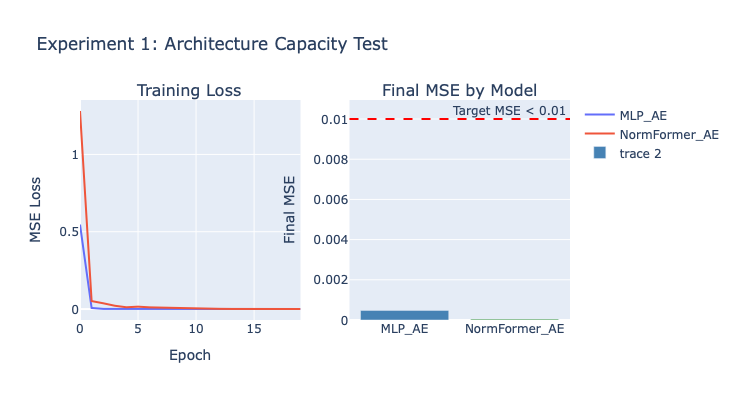

In [15]:
### Plot Experiment 1 results
fig = make_subplots(rows=1, cols=2, subplot_titles=['Training Loss', 'Final MSE by Model'])

for name, result in exp1_results.items():
    fig.add_trace(
        go.Scatter(y=result['history']['reco_loss'], name=name, mode='lines'),
        row=1, col=1
    )

fig.add_trace(
    go.Bar(
        x=list(exp1_results.keys()),
        y=[r['metrics']['overall_mse'] for r in exp1_results.values()],
        marker_color=['steelblue', 'forestgreen']
    ),
    row=1, col=2
)

### add threshold line
fig.add_hline(y=0.01, line_dash='dash', line_color='red', row=1, col=2,
              annotation_text='Target MSE < 0.01')

fig.update_layout(title='Experiment 1: Architecture Capacity Test', height=400, width=900)
fig.update_xaxes(title_text='Epoch', row=1, col=1)
fig.update_yaxes(title_text='MSE Loss', row=1, col=1)
fig.update_yaxes(title_text='Final MSE', row=1, col=2)
fig.show()


EXPERIMENT 1: Reconstruction Visualization


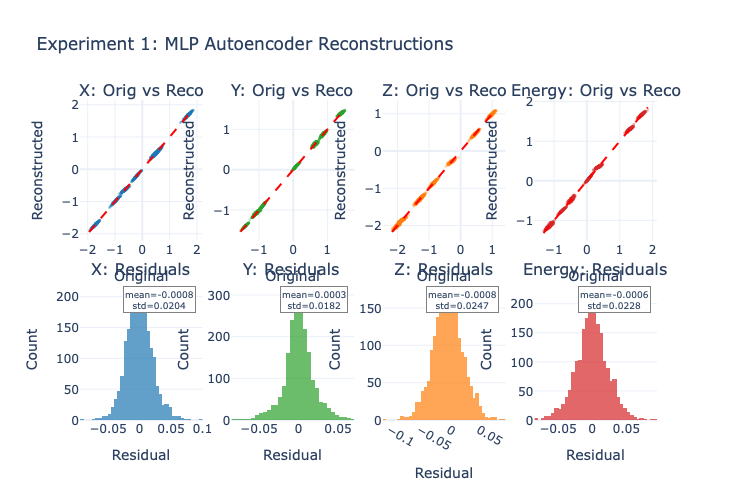

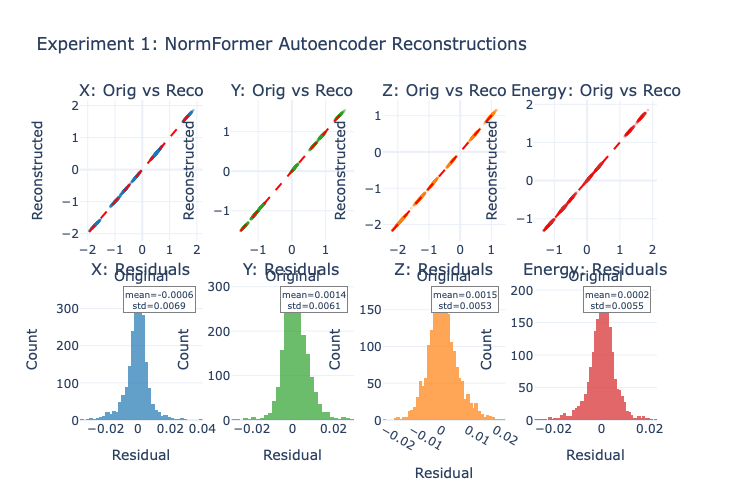

In [16]:
### Visualize Experiment 1 Reconstructions
print("\n" + "="*60)
print("EXPERIMENT 1: Reconstruction Visualization")
print("="*60)

### MLP AE reconstruction
mlp_metrics = exp1_results['MLP_AE']['metrics']
fig_mlp = plot_reconstruction_comparison(
    mlp_metrics['x_orig'], mlp_metrics['x_reco'],
    title="Experiment 1: MLP Autoencoder Reconstructions"
)
fig_mlp.show()

### NormFormer AE reconstruction  
nf_ae.eval()
with torch.no_grad():
    x_reco_nf, _ = nf_ae(X_seq.to(DEVICE), torch.ones(len(X_seq), 1, device=DEVICE))
    x_reco_nf = x_reco_nf.cpu().numpy()
    x_orig_nf = X_seq.numpy()

fig_nf = plot_reconstruction_comparison(
    x_orig_nf.reshape(-1, 4), x_reco_nf.reshape(-1, 4),
    title="Experiment 1: NormFormer Autoencoder Reconstructions"
)
fig_nf.show()

In [17]:
### Experiment 1 verdict
print("\n" + "="*60)
print("EXPERIMENT 1 VERDICT")
print("="*60)
mlp_pass = exp1_results['MLP_AE']['metrics']['overall_mse'] < 0.01
nf_pass = exp1_results['NormFormer_AE']['metrics']['overall_mse'] < 0.01

print(f"MLP AE: MSE={exp1_results['MLP_AE']['metrics']['overall_mse']:.6f} -> {'PASS' if mlp_pass else 'FAIL'}")
print(f"NormFormer AE: MSE={exp1_results['NormFormer_AE']['metrics']['overall_mse']:.6f} -> {'PASS' if nf_pass else 'FAIL'}")

if mlp_pass and nf_pass:
    print("\n-> Both architectures can learn simple reconstructions. Proceed to VQ testing.")
elif mlp_pass and not nf_pass:
    print("\n-> MLP works but NormFormer fails. Check attention/masking implementation.")
else:
    print("\n-> Basic architectures failing. Check loss function, learning rate, data.")


EXPERIMENT 1 VERDICT
MLP AE: MSE=0.000475 -> PASS
NormFormer AE: MSE=0.000038 -> PASS

-> Both architectures can learn simple reconstructions. Proceed to VQ testing.


### Experiment 2: VQ Layer Behavior Test

**Goal:** Test if VQ layer learns meaningful codebook on clustered data.

**Expected:** Codebook usage > 80%, normalized entropy > 0.8

In [18]:
print("="*60)
print("EXPERIMENT 2: VQ Layer Behavior Test")
print("="*60)
print("Testing codebook learning on clustered data...\n")

### generate clustered data with known structure
X_clusters, y_clusters = generate_gaussian_blobs(n_samples=10000, n_clusters=8, cluster_std=0.2)
cluster_loader = DataLoader(TensorDataset(X_clusters), batch_size=64, shuffle=True)

exp2_results = {}

### Test different VQ configurations
for config_name in ['default', 'fewer_codes', 'kmeans_init', 'low_commitment']:
    print(f"\nTesting VQ config: {config_name}")
    set_seed(42)
    
    vq_kwargs = VQ_CONFIGS[config_name].copy()
    
    ### use simple MLP VQ-VAE to isolate VQ behavior
    model = VQVAEMLP(
        input_dim=4,
        latent_dim=8,
        encoder_layers=[32, 32],
        decoder_layers=[32, 32],
        vq_kwargs=vq_kwargs
    )
    
    history = train_model(model, cluster_loader, n_epochs=30, lr=1e-3, alpha=5.0)
    metrics = evaluate_model(model, cluster_loader)
    
    exp2_results[config_name] = {'history': history, 'metrics': metrics}
    
    print(f"  Final MSE: {metrics['overall_mse']:.6f}")
    print(f"  Codebook usage: {metrics.get('codebook_usage', 0):.1f}%")
    print(f"  Normalized entropy: {metrics.get('entropy', 0):.3f}")

EXPERIMENT 2: VQ Layer Behavior Test
Testing codebook learning on clustered data...


Testing VQ config: default
Epoch   5/30: loss=0.003970, reco=0.001280, vq=0.000538, usage=83.8%
Epoch  10/30: loss=0.004235, reco=0.001206, vq=0.000606, usage=89.5%
Epoch  15/30: loss=0.004262, reco=0.001133, vq=0.000626, usage=88.7%
Epoch  20/30: loss=0.004479, reco=0.001080, vq=0.000680, usage=91.6%
Epoch  25/30: loss=0.004933, reco=0.001017, vq=0.000783, usage=93.4%
Epoch  30/30: loss=0.005443, reco=0.000977, vq=0.000893, usage=83.6%
  Final MSE: 0.000959
  Codebook usage: 56.2%
  Normalized entropy: 0.809

Testing VQ config: fewer_codes
Epoch   5/30: loss=0.004174, reco=0.001218, vq=0.000591, usage=100.0%
Epoch  10/30: loss=0.003870, reco=0.001171, vq=0.000540, usage=100.0%
Epoch  15/30: loss=0.003811, reco=0.001115, vq=0.000539, usage=100.0%
Epoch  20/30: loss=0.003781, reco=0.001069, vq=0.000542, usage=100.0%
Epoch  25/30: loss=0.003871, reco=0.001060, vq=0.000562, usage=100.0%
Epoch  30/30: los

/global/cfs/cdirs/m3246/mpettee/hep/particlemind/.venv/lib64/python3.11/site-packages/vqtorch/nn/utils/init.py:27: UserWarning:


codebook size > warmup samples: 512 vs 64. recommended to decrease the codebook size or increase batch size.



Epoch   5/30: loss=0.003618, reco=0.001087, vq=0.000506, usage=90.8%
Epoch  10/30: loss=0.003671, reco=0.001028, vq=0.000528, usage=91.2%
Epoch  15/30: loss=0.003827, reco=0.000967, vq=0.000572, usage=92.8%
Epoch  20/30: loss=0.003931, reco=0.000927, vq=0.000601, usage=94.7%
Epoch  25/30: loss=0.004556, reco=0.000905, vq=0.000730, usage=96.3%
Epoch  30/30: loss=0.004693, reco=0.000835, vq=0.000772, usage=91.2%
  Final MSE: 0.000831
  Codebook usage: 62.9%
  Normalized entropy: 0.836

Testing VQ config: low_commitment
Epoch   5/30: loss=0.002666, reco=0.001142, vq=0.000305, usage=91.4%
Epoch  10/30: loss=0.002661, reco=0.001106, vq=0.000311, usage=91.6%
Epoch  15/30: loss=0.002608, reco=0.001070, vq=0.000308, usage=88.5%
Epoch  20/30: loss=0.002718, reco=0.001050, vq=0.000334, usage=91.0%
Epoch  25/30: loss=0.002859, reco=0.001004, vq=0.000371, usage=94.1%
Epoch  30/30: loss=0.002877, reco=0.000927, vq=0.000390, usage=84.4%
  Final MSE: 0.000933
  Codebook usage: 53.5%
  Normalized entr

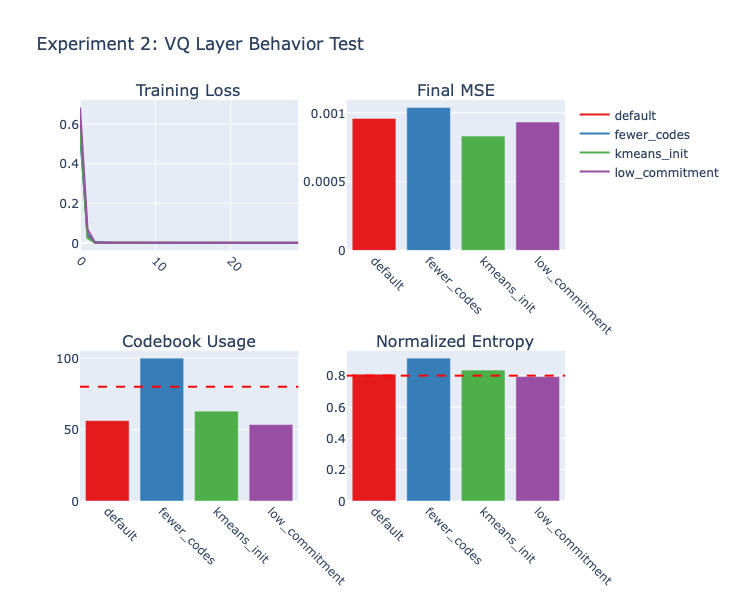

In [19]:
### Plot Experiment 2 results
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Training Loss', 'Final MSE', 'Codebook Usage', 'Normalized Entropy']
)

colors = px.colors.qualitative.Set1

for i, (name, result) in enumerate(exp2_results.items()):
    fig.add_trace(
        go.Scatter(y=result['history']['reco_loss'], name=name, mode='lines',
                   line=dict(color=colors[i])),
        row=1, col=1
    )

names = list(exp2_results.keys())
mses = [r['metrics']['overall_mse'] for r in exp2_results.values()]
usages = [r['metrics'].get('codebook_usage', 0) for r in exp2_results.values()]
entropies = [r['metrics'].get('entropy', 0) for r in exp2_results.values()]

fig.add_trace(go.Bar(x=names, y=mses, marker_color=colors[:len(names)], showlegend=False), row=1, col=2)
fig.add_trace(go.Bar(x=names, y=usages, marker_color=colors[:len(names)], showlegend=False), row=2, col=1)
fig.add_trace(go.Bar(x=names, y=entropies, marker_color=colors[:len(names)], showlegend=False), row=2, col=2)

### add threshold lines
fig.add_hline(y=80, line_dash='dash', line_color='red', row=2, col=1)
fig.add_hline(y=0.8, line_dash='dash', line_color='red', row=2, col=2)

fig.update_layout(title='Experiment 2: VQ Layer Behavior Test', height=600, width=900)
fig.update_xaxes(tickangle=45)
fig.show()


EXPERIMENT 2: Reconstruction Visualization (Best Config)


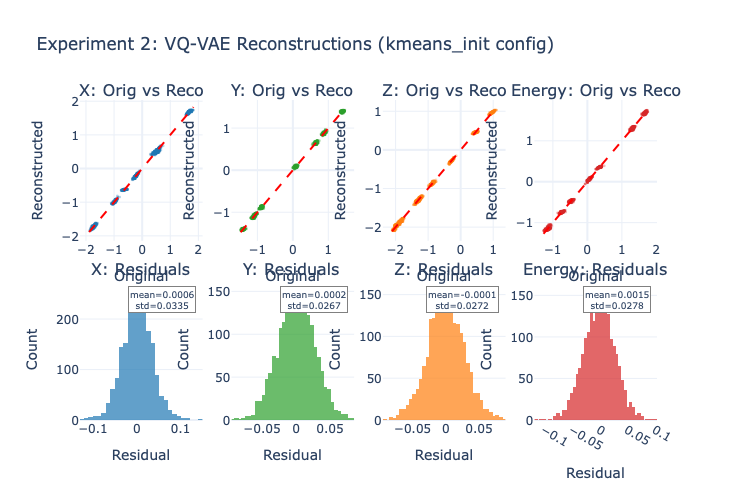

In [20]:
### Visualize Experiment 2 Reconstructions (best config)
print("\n" + "="*60)
print("EXPERIMENT 2: Reconstruction Visualization (Best Config)")
print("="*60)

best_config = min(exp2_results.keys(), key=lambda k: exp2_results[k]['metrics']['overall_mse'])
best_metrics = exp2_results[best_config]['metrics']

fig_exp2 = plot_reconstruction_comparison(
    best_metrics['x_orig'], best_metrics['x_reco'],
    title=f"Experiment 2: VQ-VAE Reconstructions ({best_config} config)"
)
fig_exp2.show()


Visualizing latent space for best config: kmeans_init


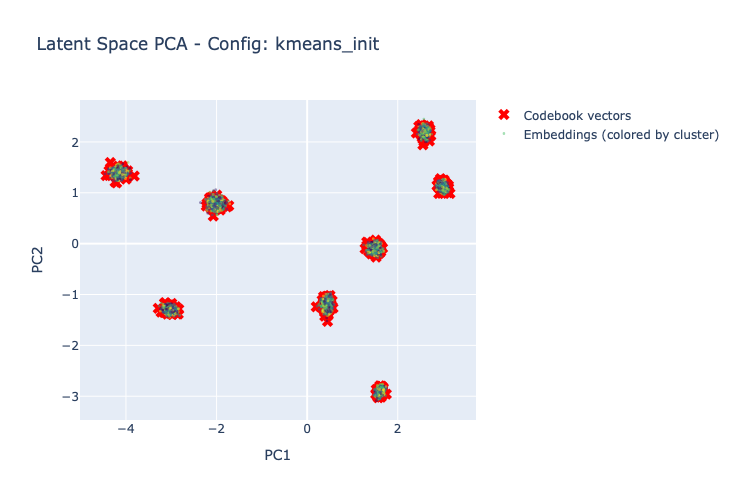

In [21]:
### Visualize latent space for best config
best_config = min(exp2_results.keys(), key=lambda k: exp2_results[k]['metrics']['overall_mse'])
best_metrics = exp2_results[best_config]['metrics']

print(f"\nVisualizing latent space for best config: {best_config}")

if 'z' in best_metrics and 'codebook' in best_metrics:
    z = best_metrics['z']
    codebook = best_metrics['codebook']
    codes = best_metrics['codes']
    
    ### PCA projection
    pca = PCA(n_components=2)
    combined = np.vstack([z[:5000], codebook])
    combined_pca = pca.fit_transform(combined)
    
    z_pca = combined_pca[:5000]
    codebook_pca = combined_pca[5000:]
    
    fig = go.Figure()
    
    ### codebook vectors
    fig.add_trace(go.Scatter(
        x=codebook_pca[:, 0], y=codebook_pca[:, 1],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x'),
        name='Codebook vectors'
    ))

    ### embeddings colored by cluster label
    fig.add_trace(go.Scatter(
        x=z_pca[:, 0], y=z_pca[:, 1],
        mode='markers',
        marker=dict(size=3, color=y_clusters[:5000].numpy(), colorscale='Viridis', opacity=0.5),
        name='Embeddings (colored by cluster)'
    ))
    
    fig.update_layout(
        title=f'Latent Space PCA - Config: {best_config}',
        xaxis_title='PC1', yaxis_title='PC2',
        height=500, width=700
    )
    fig.show()

In [22]:
### Experiment 2 verdict
print("\n" + "="*60)
print("EXPERIMENT 2 VERDICT")
print("="*60)

for name, result in exp2_results.items():
    m = result['metrics']
    usage_pass = m.get('codebook_usage', 0) > 80
    entropy_pass = m.get('entropy', 0) > 0.8
    mse_pass = m['overall_mse'] < 0.1
    
    status = 'PASS' if (usage_pass and entropy_pass and mse_pass) else 'PARTIAL' if mse_pass else 'FAIL'
    print(f"{name}: MSE={m['overall_mse']:.4f}, Usage={m.get('codebook_usage', 0):.1f}%, "
          f"Entropy={m.get('entropy', 0):.3f} -> {status}")

best = min(exp2_results.items(), key=lambda x: x[1]['metrics']['overall_mse'])
print(f"\n-> Best config: {best[0]} with MSE={best[1]['metrics']['overall_mse']:.6f}")


EXPERIMENT 2 VERDICT
default: MSE=0.0010, Usage=56.2%, Entropy=0.809 -> PARTIAL
fewer_codes: MSE=0.0010, Usage=100.0%, Entropy=0.912 -> PASS
kmeans_init: MSE=0.0008, Usage=62.9%, Entropy=0.836 -> PARTIAL
low_commitment: MSE=0.0009, Usage=53.5%, Entropy=0.794 -> PARTIAL

-> Best config: kmeans_init with MSE=0.000831


### Experiment 3: Variable-Length Handling Test

**Goal:** Test if masking works correctly with variable-length sequences.

**Expected:** MSE should not correlate with sequence length.

In [23]:
print("="*60)
print("EXPERIMENT 3: Variable-Length Handling Test")
print("="*60)
print("Testing masking with variable-length sequences...\n")

### generate variable-length data
var_data = generate_variable_length_blobs(n_events=500, min_len=20, max_len=150, n_clusters=8)

### create dataloader
class DictDataset(torch.utils.data.Dataset):
    def __init__(self, data_dict):
        self.data = data_dict
    def __len__(self):
        return len(self.data['features'])
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.data.items() if k != 'labels'}

var_dataset = DictDataset(var_data)
var_loader = DataLoader(var_dataset, batch_size=32, shuffle=True)

### train full VQVAENormFormer
set_seed(42)
model = VQVAENormFormer(
    input_dim=4,
    latent_dim=16,
    hidden_dim=64,
    num_heads=2,
    num_blocks=2,
    vq_kwargs={'num_codes': 128, 'beta': 0.9, 'dim': -1}
)

history = train_model(model, var_loader, n_epochs=30, lr=1e-3, alpha=5.0, use_mask=True)
print(f"\nFinal training loss: {history['train_loss'][-1]:.6f}")
print(f"Final reco loss: {history['reco_loss'][-1]:.6f}")

EXPERIMENT 3: Variable-Length Handling Test
Testing masking with variable-length sequences...

Epoch   5/30: loss=20.962605, reco=1.048165, vq=3.982888, usage=21.1%
Epoch  10/30: loss=36.389175, reco=1.555307, vq=6.966774, usage=12.5%
Epoch  15/30: loss=29.346459, reco=0.971058, vq=5.675080, usage=11.7%
Epoch  20/30: loss=29.885487, reco=0.547158, vq=5.867666, usage=10.9%
Epoch  25/30: loss=7.579755, reco=0.371975, vq=1.441556, usage=11.7%
Epoch  30/30: loss=7.468939, reco=0.380278, vq=1.417732, usage=10.9%

Final training loss: 7.468939
Final reco loss: 0.380278



EXPERIMENT 3: Reconstruction Visualization


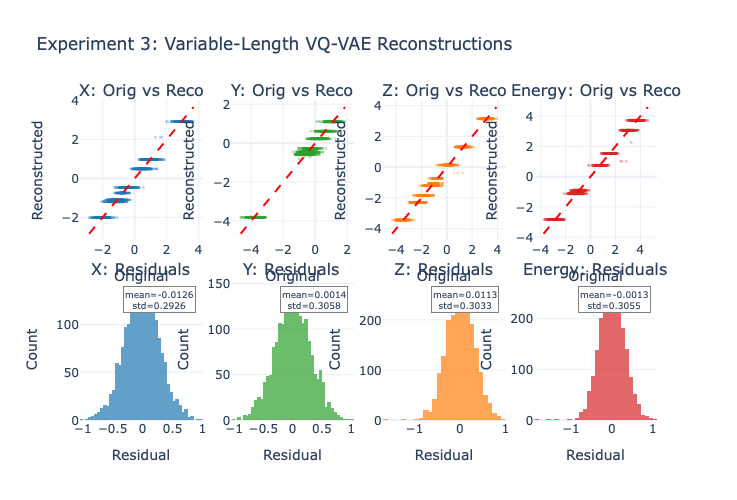

In [24]:
### Visualize Experiment 3 Reconstructions
print("\n" + "="*60)
print("EXPERIMENT 3: Reconstruction Visualization")
print("="*60)

### get reconstructions from the trained model
model.eval()
exp3_orig = []
exp3_reco = []

with torch.no_grad():
    for i in range(min(100, len(var_data['features']))):
        x = var_data['features'][i:i+1].to(DEVICE)
        mask = var_data['masks'][i:i+1].to(DEVICE)
        x_reco, _ = model(x, mask)
        
        valid = mask[0] == 1
        exp3_orig.append(x[0, valid].cpu().numpy())
        exp3_reco.append(x_reco[0, valid].cpu().numpy())

exp3_orig = np.vstack(exp3_orig)
exp3_reco = np.vstack(exp3_reco)

fig_exp3 = plot_reconstruction_comparison(
    exp3_orig, exp3_reco,
    title="Experiment 3: Variable-Length VQ-VAE Reconstructions"
)
fig_exp3.show()

In [29]:
### Analyze MSE vs sequence length
model.eval()

seq_lengths = []
mse_by_event = []

with torch.no_grad():
    for i in range(len(var_data['features'])):
        x = var_data['features'][i:i+1].to(DEVICE)
        mask = var_data['masks'][i:i+1].to(DEVICE)
        
        x_reco, _ = model(x, mask)
        
        valid = mask[0] == 1
        mse = ((x_reco[0, valid] - x[0, valid]) ** 2).mean().item()
        
        seq_lengths.append(int(valid.sum().item()))
        mse_by_event.append(mse)

seq_lengths = np.array(seq_lengths)
mse_by_event = np.array(mse_by_event)

### compute correlation
correlation = np.corrcoef(seq_lengths, mse_by_event)[0, 1]

print(f"\nCorrelation between sequence length and MSE: {correlation:.4f}")


Correlation between sequence length and MSE: 0.0218


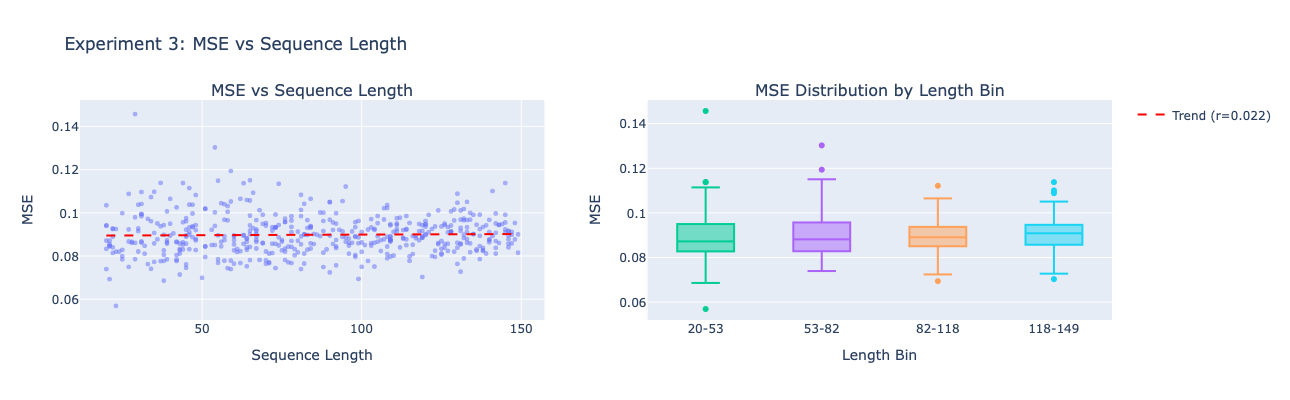

In [30]:
### Plot MSE vs sequence length
fig = make_subplots(rows=1, cols=2, subplot_titles=['MSE vs Sequence Length', 'MSE Distribution by Length Bin'])

### scatter plot
fig.add_trace(
    go.Scatter(x=seq_lengths, y=mse_by_event, mode='markers', 
               marker=dict(size=5, opacity=0.5), showlegend=False),
    row=1, col=1
)

### add trend line
z = np.polyfit(seq_lengths, mse_by_event, 1)
p = np.poly1d(z)
x_line = np.linspace(seq_lengths.min(), seq_lengths.max(), 100)
fig.add_trace(
    go.Scatter(x=x_line, y=p(x_line), mode='lines', 
               line=dict(color='red', dash='dash'), name=f'Trend (r={correlation:.3f})'),
    row=1, col=1
)

### box plot by length bins
bins = np.percentile(seq_lengths, [0, 25, 50, 75, 100])
bin_labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
bin_indices = np.digitize(seq_lengths, bins[:-1]) - 1

for i, label in enumerate(bin_labels):
    mask = bin_indices == i
    fig.add_trace(
        go.Box(y=mse_by_event[mask], name=label, showlegend=False),
        row=1, col=2
    )

fig.update_layout(title='Experiment 3: MSE vs Sequence Length', height=400, width=900)
fig.update_xaxes(title_text='Sequence Length', row=1, col=1)
fig.update_yaxes(title_text='MSE', row=1, col=1)
fig.update_xaxes(title_text='Length Bin', row=1, col=2)
fig.update_yaxes(title_text='MSE', row=1, col=2)
fig.show()

In [33]:
### Experiment 3 verdict
print("\n" + "="*60)
print("EXPERIMENT 3 VERDICT")
print("="*60)

corr_threshold = 0.3
corr_pass = abs(correlation) < corr_threshold

print(f"Correlation: {correlation:.4f} (threshold: |r| < {corr_threshold})")
print(f"Status: {'PASS' if corr_pass else 'FAIL'}")

if corr_pass:
    print("\n-> Masking works correctly. MSE doesn't depend on sequence length.")
else:
    if correlation > 0:
        print("\n-> Longer sequences have higher MSE. Check attention scaling.")
    else:
        print("\n-> Shorter sequences have higher MSE. Check padding handling.")


EXPERIMENT 3 VERDICT
Correlation: 0.0218 (threshold: |r| < 0.3)
Status: PASS

-> Masking works correctly. MSE doesn't depend on sequence length.


### Experiment 4: Feature Scaling Ablation

**Goal:** Determine if asymmetric feature scaling causes issues.

This is the KEY experiment - the real data has:
- Positions scaled by /1000 (small values)
- Energy scaled by *100 (large values)

**Expected:** Normalized features should have much lower MSE than asymmetric features.

In [36]:
print("="*60)
print("EXPERIMENT 4: Feature Scaling Ablation")
print("="*60)
print("Testing impact of asymmetric vs normalized feature scaling...\n")

exp4_results = {}

### Test asymmetric scaling (like real data)
print("Testing ASYMMETRIC scaling (like real calorimeter data)...")
X_asym = generate_asymmetric_scaled_data(10000)
print(f"  Feature stds: {X_asym.std(dim=0).numpy()}")
print(f"  Scale ratio (energy/pos): {X_asym[:, 3].std() / X_asym[:, :3].std():.1f}x")

X_asym_seq = X_asym.unsqueeze(1)  ### (N, 1, 4)
asym_loader = DataLoader(TensorDataset(X_asym_seq), batch_size=64, shuffle=True)

set_seed(42)
model_asym = VQVAENormFormer(
    input_dim=4, latent_dim=16, hidden_dim=64,
    num_heads=2, num_blocks=2,
    vq_kwargs={'num_codes': 128, 'beta': 0.9, 'dim': -1}
)
history_asym = train_model(model_asym, asym_loader, n_epochs=30, lr=1e-3, alpha=5.0)

### evaluate per-feature
model_asym.eval()
with torch.no_grad():
    x_reco, _ = model_asym(X_asym_seq.to(DEVICE), torch.ones(len(X_asym_seq), 1, device=DEVICE))
    asym_mse_total = ((x_reco.cpu() - X_asym_seq) ** 2).mean().item()
    asym_mse_per_feat = [((x_reco.cpu()[:, 0, i] - X_asym_seq[:, 0, i]) ** 2).mean().item() for i in range(4)]

exp4_results['asymmetric'] = {
    'history': history_asym,
    'mse_total': asym_mse_total,
    'mse_per_feature': asym_mse_per_feat,
    'feature_stds': X_asym.std(dim=0).numpy()
}
print(f"  Total MSE: {asym_mse_total:.4f}")
print(f"  Per-feature MSE: pos={asym_mse_per_feat[:3]}, energy={asym_mse_per_feat[3]:.4f}")

EXPERIMENT 4: Feature Scaling Ablation
Testing impact of asymmetric vs normalized feature scaling...

Testing ASYMMETRIC scaling (like real calorimeter data)...
  Feature stds: [ 1.7230849  1.7323275  1.7272805 98.81393  ]
  Scale ratio (energy/pos): 57.2x
Epoch   5/30: loss=104548607.159236, reco=9861.727769, vq=20907749.057325, usage=9.4%
Epoch  10/30: loss=1450494.060111, reco=9829.913487, vq=288132.831260, usage=33.6%
Epoch  15/30: loss=1976345.125000, reco=9815.887873, vq=393305.846039, usage=21.1%
Epoch  20/30: loss=2089951.644506, reco=9773.277048, vq=416035.671975, usage=16.4%
Epoch  25/30: loss=2218891.556529, reco=9764.168270, vq=441825.481091, usage=13.3%
Epoch  30/30: loss=2218003.419984, reco=9772.088270, vq=441646.264630, usage=8.6%
  Total MSE: 2442.6497
  Per-feature MSE: pos=[2.973262071609497, 3.002713918685913, 2.987945079803467], energy=9761.6348


In [38]:
### Test normalized scaling
print("\nTesting NORMALIZED scaling...")
X_norm = generate_normalized_data(10000)
print(f"  Feature stds: {X_norm.std(dim=0).numpy()}")

X_norm_seq = X_norm.unsqueeze(1)
norm_loader = DataLoader(TensorDataset(X_norm_seq), batch_size=64, shuffle=True)

set_seed(42)
model_norm = VQVAENormFormer(
    input_dim=4, latent_dim=16, hidden_dim=64,
    num_heads=2, num_blocks=2,
    vq_kwargs={'num_codes': 128, 'beta': 0.9, 'dim': -1}
)
history_norm = train_model(model_norm, norm_loader, n_epochs=30, lr=1e-3, alpha=5.0)

### evaluate per-feature
model_norm.eval()
with torch.no_grad():
    x_reco, _ = model_norm(X_norm_seq.to(DEVICE), torch.ones(len(X_norm_seq), 1, device=DEVICE))
    norm_mse_total = ((x_reco.cpu() - X_norm_seq) ** 2).mean().item()
    norm_mse_per_feat = [((x_reco.cpu()[:, 0, i] - X_norm_seq[:, 0, i]) ** 2).mean().item() for i in range(4)]

exp4_results['normalized'] = {
    'history': history_norm,
    'mse_total': norm_mse_total,
    'mse_per_feature': norm_mse_per_feat,
    'feature_stds': X_norm.std(dim=0).numpy()
}
print(f"  Total MSE: {norm_mse_total:.4f}")
print(f"  Per-feature MSE: {norm_mse_per_feat}")


Testing NORMALIZED scaling...
  Feature stds: [1.00005 1.00005 1.00005 1.00005]
Epoch   5/30: loss=20.253077, reco=0.970305, vq=3.856554, usage=28.1%
Epoch  10/30: loss=12.354912, reco=0.841091, vq=2.302764, usage=27.3%
Epoch  15/30: loss=10.510506, reco=0.806263, vq=1.940849, usage=27.3%
Epoch  20/30: loss=10.111051, reco=0.798267, vq=1.862557, usage=28.1%
Epoch  25/30: loss=9.908884, reco=0.791556, vq=1.823466, usage=29.7%
Epoch  30/30: loss=9.862732, reco=0.787670, vq=1.815012, usage=28.9%
  Total MSE: 0.1950
  Per-feature MSE: [0.19111567735671997, 0.19029100239276886, 0.1866786628961563, 0.21180568635463715]



EXPERIMENT 4: Reconstruction Comparison (Key Experiment)


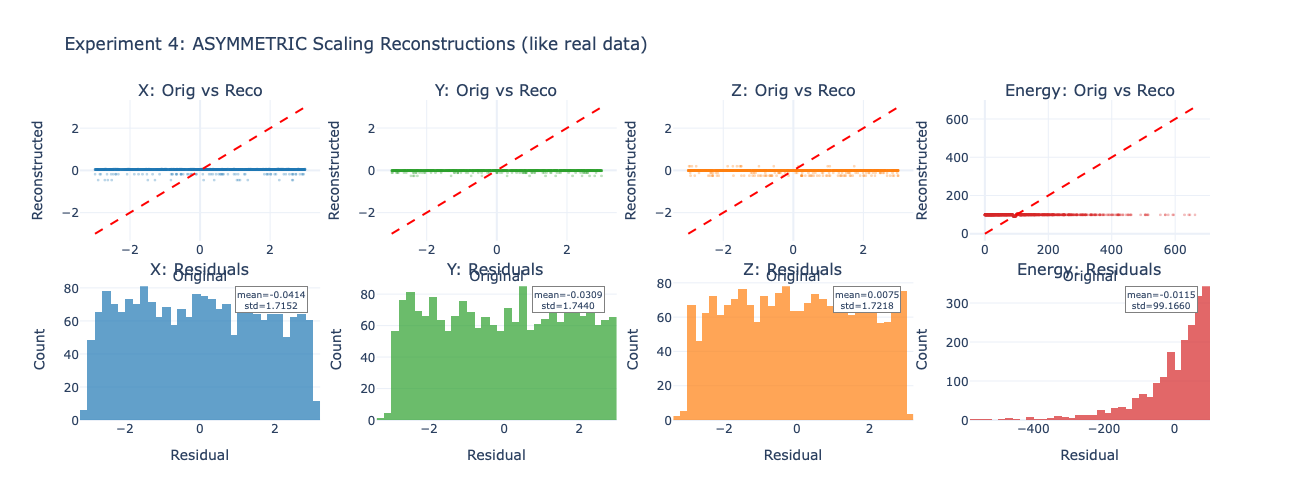

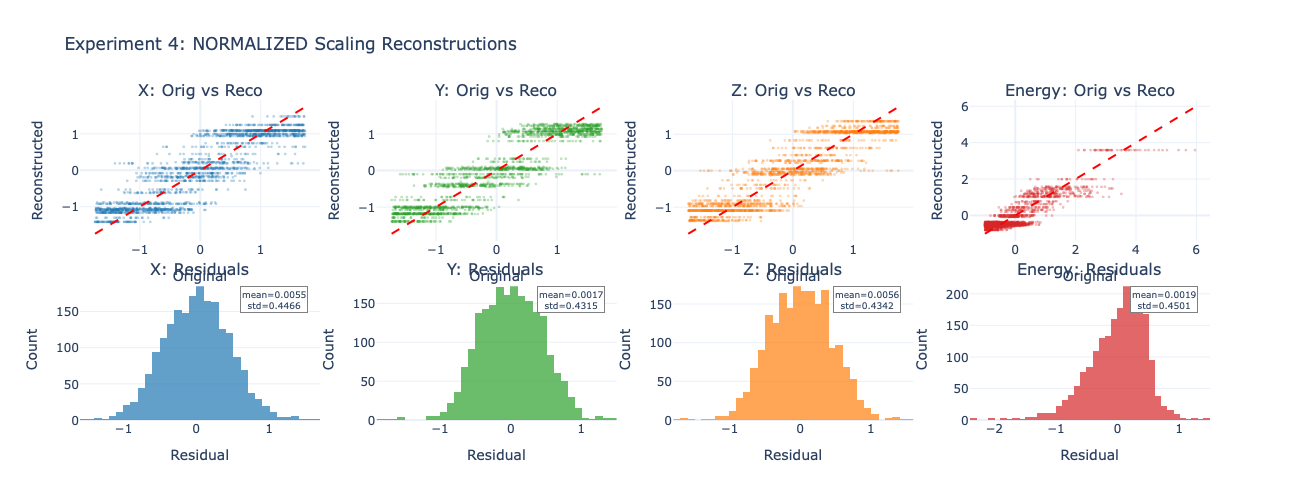


Compare the residual distributions - especially for Energy!
Asymmetric scaling has much larger energy residuals, just like the real data.


In [39]:
### Visualize Experiment 4 Reconstructions (Asymmetric vs Normalized)
print("\n" + "="*60)
print("EXPERIMENT 4: Reconstruction Comparison (Key Experiment)")
print("="*60)

### Asymmetric scaling reconstructions
model_asym.eval()
with torch.no_grad():
    x_reco_asym, _ = model_asym(X_asym_seq.to(DEVICE), torch.ones(len(X_asym_seq), 1, device=DEVICE))
    x_reco_asym = x_reco_asym.cpu().numpy()

fig_asym = plot_reconstruction_comparison(
    X_asym_seq.numpy().reshape(-1, 4), x_reco_asym.reshape(-1, 4),
    title="Experiment 4: ASYMMETRIC Scaling Reconstructions (like real data)"
)
fig_asym.show()

### Normalized scaling reconstructions
model_norm.eval()
with torch.no_grad():
    x_reco_norm, _ = model_norm(X_norm_seq.to(DEVICE), torch.ones(len(X_norm_seq), 1, device=DEVICE))
    x_reco_norm = x_reco_norm.cpu().numpy()

fig_norm = plot_reconstruction_comparison(
    X_norm_seq.numpy().reshape(-1, 4), x_reco_norm.reshape(-1, 4),
    title="Experiment 4: NORMALIZED Scaling Reconstructions"
)
fig_norm.show()

print("\nCompare the residual distributions - especially for Energy!")
print("Asymmetric scaling has much larger energy residuals, just like the real data.")

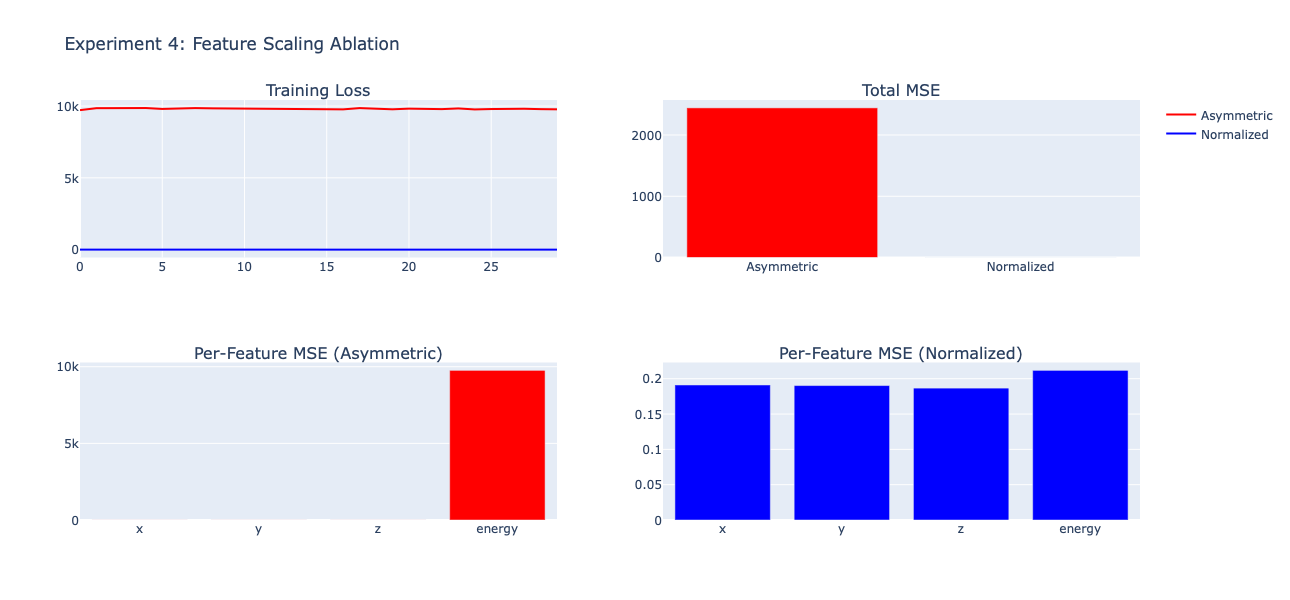

In [40]:
### Plot Experiment 4 results
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Training Loss', 'Total MSE', 'Per-Feature MSE (Asymmetric)', 'Per-Feature MSE (Normalized)']
)

### training curves
fig.add_trace(
    go.Scatter(y=exp4_results['asymmetric']['history']['reco_loss'], 
               name='Asymmetric', line=dict(color='red')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(y=exp4_results['normalized']['history']['reco_loss'], 
               name='Normalized', line=dict(color='blue')),
    row=1, col=1
)

### total MSE comparison
fig.add_trace(
    go.Bar(x=['Asymmetric', 'Normalized'], 
           y=[exp4_results['asymmetric']['mse_total'], exp4_results['normalized']['mse_total']],
           marker_color=['red', 'blue'], showlegend=False),
    row=1, col=2
)

### per-feature MSE
feat_names = ['x', 'y', 'z', 'energy']
fig.add_trace(
    go.Bar(x=feat_names, y=exp4_results['asymmetric']['mse_per_feature'],
           marker_color='red', name='Asymmetric', showlegend=False),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=feat_names, y=exp4_results['normalized']['mse_per_feature'],
           marker_color='blue', name='Normalized', showlegend=False),
    row=2, col=2
)

fig.update_layout(title='Experiment 4: Feature Scaling Ablation', height=600, width=900)
fig.show()

In [41]:
### Experiment 4 verdict
print("\n" + "="*60)
print("EXPERIMENT 4 VERDICT")
print("="*60)

asym_mse = exp4_results['asymmetric']['mse_total']
norm_mse = exp4_results['normalized']['mse_total']
ratio = asym_mse / norm_mse if norm_mse > 0 else float('inf')

print(f"Asymmetric MSE: {asym_mse:.6f}")
print(f"Normalized MSE: {norm_mse:.6f}")
print(f"Ratio: {ratio:.2f}x")

print("\nPer-feature MSE breakdown:")
print(f"  Asymmetric: pos={exp4_results['asymmetric']['mse_per_feature'][:3]}, "
      f"energy={exp4_results['asymmetric']['mse_per_feature'][3]:.4f}")
print(f"  Normalized: {exp4_results['normalized']['mse_per_feature']}")

if ratio > 2:
    print(f"\n-> SIGNIFICANT SCALING IMPACT: {ratio:.1f}x worse with asymmetric scaling!")
    print("-> RECOMMENDATION: Add feature normalization to real data pipeline.")
else:
    print("\n-> Scaling has modest impact. Look at other factors.")


EXPERIMENT 4 VERDICT
Asymmetric MSE: 2442.649658
Normalized MSE: 0.194973
Ratio: 12528.16x

Per-feature MSE breakdown:
  Asymmetric: pos=[2.973262071609497, 3.002713918685913, 2.987945079803467], energy=9761.6348
  Normalized: [0.19111567735671997, 0.19029100239276886, 0.1866786628961563, 0.21180568635463715]

-> SIGNIFICANT SCALING IMPACT: 12528.2x worse with asymmetric scaling!
-> RECOMMENDATION: Add feature normalization to real data pipeline.


### Experiment 5: Progressive Difficulty Test

**Goal:** Find the complexity threshold where the model starts to fail.

In [45]:
print("="*60)
print("EXPERIMENT 5: Progressive Difficulty Test")
print("="*60)
print("Testing model on progressively harder datasets...\n")

exp5_results = {}

### Level 1: Simple Gaussian blobs (normalized)
print("Level 1: Gaussian blobs (normalized)")
X_l1, _ = generate_gaussian_blobs(5000, n_clusters=8, cluster_std=0.3)
X_l1_seq = X_l1.unsqueeze(1)
l1_loader = DataLoader(TensorDataset(X_l1_seq), batch_size=64, shuffle=True)

set_seed(42)
model_l1 = VQVAENormFormer(
    input_dim=4, latent_dim=16, hidden_dim=64,
    num_heads=2, num_blocks=2,
    vq_kwargs={'num_codes': 128, 'beta': 0.9, 'dim': -1}
)
history_l1 = train_model(model_l1, l1_loader, n_epochs=20, lr=1e-3, alpha=5.0, verbose=False)

model_l1.eval()
with torch.no_grad():
    x_reco, vq_out = model_l1(X_l1_seq.to(DEVICE), torch.ones(len(X_l1_seq), 1, device=DEVICE))
    l1_mse = ((x_reco.cpu() - X_l1_seq) ** 2).mean().item()
    l1_codes = vq_out['q'].cpu().numpy()

exp5_results['L1_blobs'] = {'mse': l1_mse, 'codebook_usage': len(np.unique(l1_codes)) / 128 * 100}
print(f"  MSE: {l1_mse:.6f}, Codebook usage: {exp5_results['L1_blobs']['codebook_usage']:.1f}%")

EXPERIMENT 5: Progressive Difficulty Test
Testing model on progressively harder datasets...

Level 1: Gaussian blobs (normalized)
  MSE: 0.003682, Codebook usage: 6.2%


In [47]:
### Level 2: Variable-length sequences
print("\nLevel 2: Variable-length sequences")
l2_data = generate_variable_length_blobs(500, min_len=20, max_len=100, n_clusters=8)
l2_dataset = DictDataset(l2_data)
l2_loader = DataLoader(l2_dataset, batch_size=32, shuffle=True)

set_seed(42)
model_l2 = VQVAENormFormer(
    input_dim=4, latent_dim=16, hidden_dim=64,
    num_heads=2, num_blocks=2,
    vq_kwargs={'num_codes': 128, 'beta': 0.9, 'dim': -1}
)
history_l2 = train_model(model_l2, l2_loader, n_epochs=20, lr=1e-3, alpha=5.0, use_mask=True, verbose=False)

metrics_l2 = evaluate_model(model_l2, l2_loader, use_mask=True)
exp5_results['L2_variable'] = {'mse': metrics_l2['overall_mse'], 'codebook_usage': metrics_l2.get('codebook_usage', 0)}
print(f"  MSE: {metrics_l2['overall_mse']:.6f}, Codebook usage: {exp5_results['L2_variable']['codebook_usage']:.1f}%")


Level 2: Variable-length sequences
  MSE: 0.205179, Codebook usage: 9.4%


In [48]:
### Level 3: Synthetic calorimeter (with asymmetric scaling like real data)
print("\nLevel 3: Synthetic calorimeter (asymmetric scaling)")
l3_data = generate_synthetic_calorimeter(300, min_hits=50, max_hits=200)
l3_dataset = DictDataset(l3_data)
l3_loader = DataLoader(l3_dataset, batch_size=32, shuffle=True)

set_seed(42)
model_l3 = VQVAENormFormer(
    input_dim=4, latent_dim=16, hidden_dim=64,
    num_heads=2, num_blocks=2,
    vq_kwargs={'num_codes': 128, 'beta': 0.9, 'dim': -1}
)
history_l3 = train_model(model_l3, l3_loader, n_epochs=20, lr=1e-3, alpha=5.0, use_mask=True, verbose=False)

metrics_l3 = evaluate_model(model_l3, l3_loader, use_mask=True)
exp5_results['L3_calo_asym'] = {'mse': metrics_l3['overall_mse'], 'codebook_usage': metrics_l3.get('codebook_usage', 0)}
print(f"  MSE: {metrics_l3['overall_mse']:.6f}, Codebook usage: {exp5_results['L3_calo_asym']['codebook_usage']:.1f}%")


Level 3: Synthetic calorimeter (asymmetric scaling)
  MSE: 548.377319, Codebook usage: 3.9%



EXPERIMENT 5: Reconstruction Visualization by Difficulty


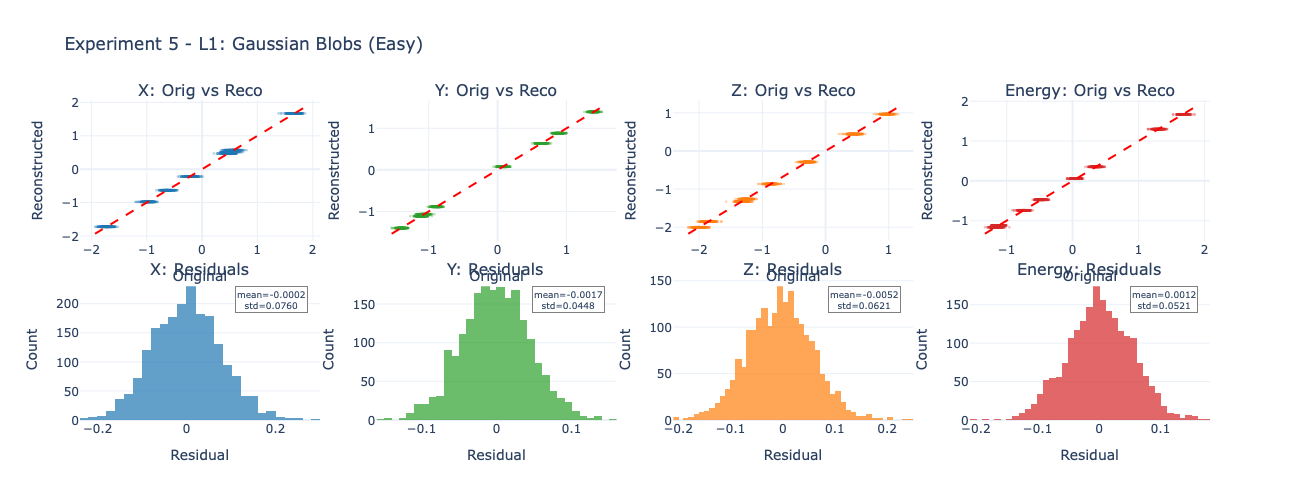

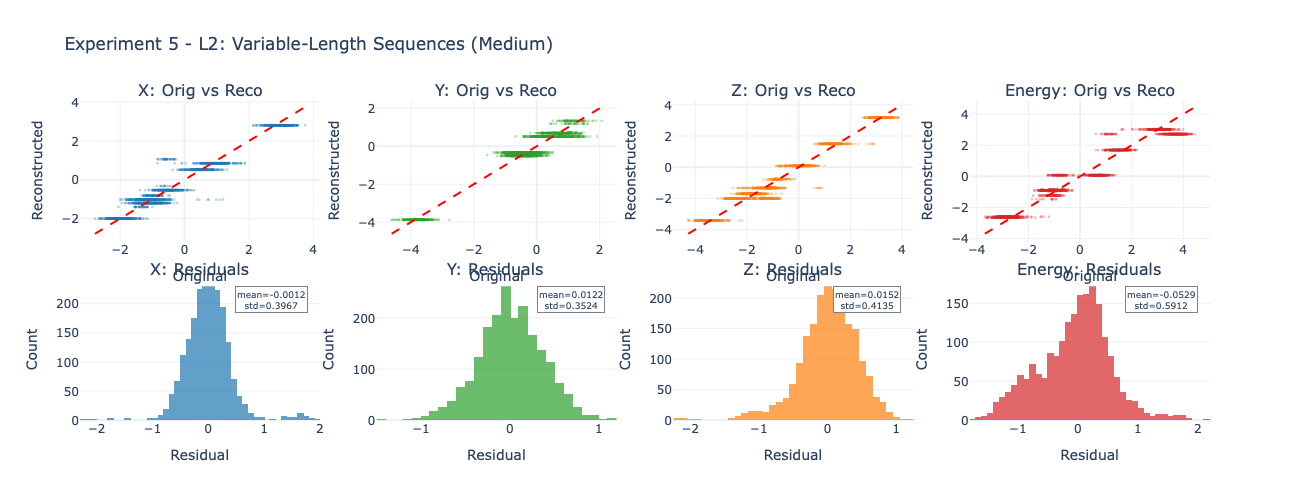

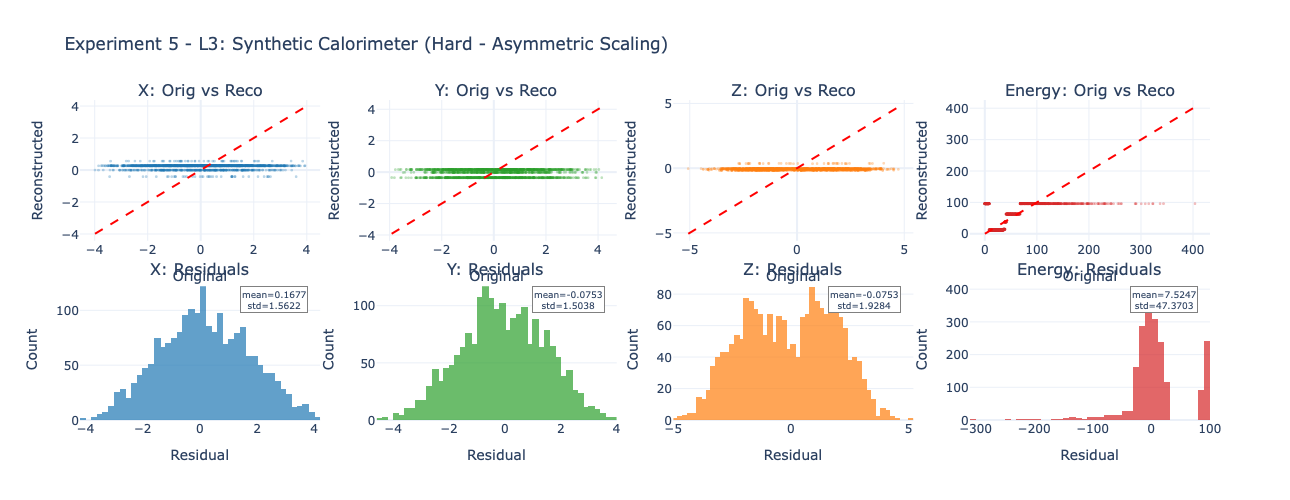


Note how reconstruction quality degrades with asymmetric scaling in L3!


In [49]:
### Visualize Experiment 5 Reconstructions (Progressive Difficulty)
print("\n" + "="*60)
print("EXPERIMENT 5: Reconstruction Visualization by Difficulty")
print("="*60)

### L1: Gaussian blobs
model_l1.eval()
with torch.no_grad():
    x_reco_l1, _ = model_l1(X_l1_seq.to(DEVICE), torch.ones(len(X_l1_seq), 1, device=DEVICE))
    x_reco_l1 = x_reco_l1.cpu().numpy()

fig_l1 = plot_reconstruction_comparison(
    X_l1_seq.numpy().reshape(-1, 4), x_reco_l1.reshape(-1, 4),
    title="Experiment 5 - L1: Gaussian Blobs (Easy)"
)
fig_l1.show()

### L2: Variable-length
metrics_l2_vis = evaluate_model(model_l2, l2_loader, use_mask=True)
fig_l2 = plot_reconstruction_comparison(
    metrics_l2_vis['x_orig'], metrics_l2_vis['x_reco'],
    title="Experiment 5 - L2: Variable-Length Sequences (Medium)"
)
fig_l2.show()

### L3: Synthetic calorimeter
metrics_l3_vis = evaluate_model(model_l3, l3_loader, use_mask=True)
fig_l3 = plot_reconstruction_comparison(
    metrics_l3_vis['x_orig'], metrics_l3_vis['x_reco'],
    title="Experiment 5 - L3: Synthetic Calorimeter (Hard - Asymmetric Scaling)"
)
fig_l3.show()

print("\nNote how reconstruction quality degrades with asymmetric scaling in L3!")

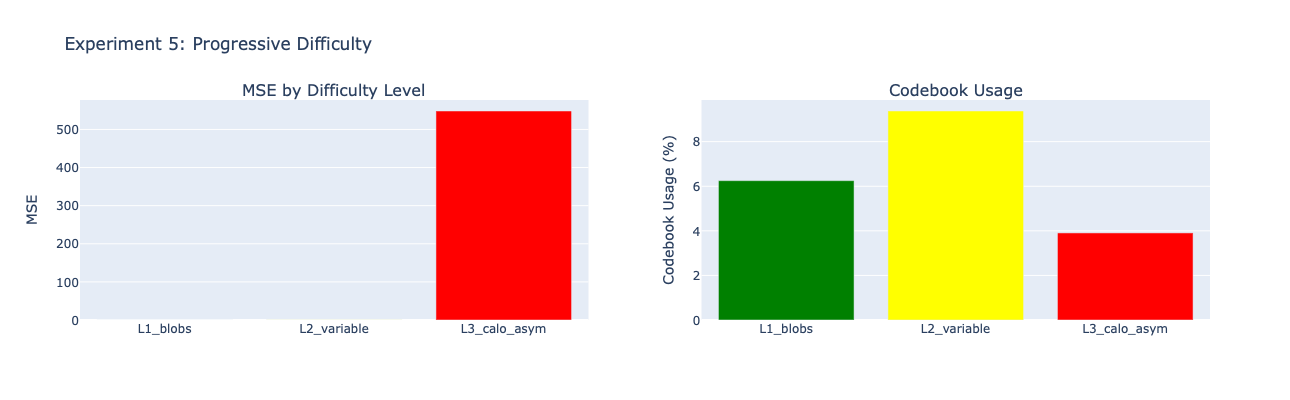

In [50]:
### Plot progressive difficulty results
fig = make_subplots(rows=1, cols=2, subplot_titles=['MSE by Difficulty Level', 'Codebook Usage'])

levels = list(exp5_results.keys())
mses = [exp5_results[l]['mse'] for l in levels]
usages = [exp5_results[l]['codebook_usage'] for l in levels]

fig.add_trace(go.Bar(x=levels, y=mses, marker_color=['green', 'yellow', 'red']), row=1, col=1)
fig.add_trace(go.Bar(x=levels, y=usages, marker_color=['green', 'yellow', 'red']), row=1, col=2)

fig.update_layout(title='Experiment 5: Progressive Difficulty', height=400, width=800, showlegend=False)
fig.update_yaxes(title_text='MSE', row=1, col=1)
fig.update_yaxes(title_text='Codebook Usage (%)', row=1, col=2)
fig.show()

In [51]:
### Experiment 5 verdict
print("\n" + "="*60)
print("EXPERIMENT 5 VERDICT")
print("="*60)

for level, result in exp5_results.items():
    print(f"{level}: MSE={result['mse']:.6f}, Usage={result['codebook_usage']:.1f}%")

### identify failure point
mse_threshold = 1.0
failed_levels = [l for l, r in exp5_results.items() if r['mse'] > mse_threshold]

if failed_levels:
    print(f"\n-> Model struggles at: {failed_levels}")
    print("-> This indicates the complexity threshold where improvements are needed.")
else:
    print("\n-> Model handles all difficulty levels reasonably.")
    print("-> The issue may be specific to real data characteristics.")


EXPERIMENT 5 VERDICT
L1_blobs: MSE=0.003682, Usage=6.2%
L2_variable: MSE=0.205179, Usage=9.4%
L3_calo_asym: MSE=548.377319, Usage=3.9%

-> Model struggles at: ['L3_calo_asym']
-> This indicates the complexity threshold where improvements are needed.


---
## Summary & Recommendations

In [52]:
print("="*70)
print("DIAGNOSTIC SUMMARY")
print("="*70)

print("\n1. ARCHITECTURE CAPACITY (Experiment 1):")
print(f"   MLP AE: {exp1_results['MLP_AE']['metrics']['overall_mse']:.6f}")
print(f"   NormFormer AE: {exp1_results['NormFormer_AE']['metrics']['overall_mse']:.6f}")
arch_ok = all(r['metrics']['overall_mse'] < 0.1 for r in exp1_results.values())
print(f"   -> {'OK' if arch_ok else 'ISSUE DETECTED'}")

print("\n2. VQ LAYER BEHAVIOR (Experiment 2):")
best_vq = min(exp2_results.items(), key=lambda x: x[1]['metrics']['overall_mse'])
print(f"   Best config: {best_vq[0]} with MSE={best_vq[1]['metrics']['overall_mse']:.6f}")
print(f"   Usage: {best_vq[1]['metrics'].get('codebook_usage', 0):.1f}%, Entropy: {best_vq[1]['metrics'].get('entropy', 0):.3f}")

print("\n3. VARIABLE-LENGTH HANDLING (Experiment 3):")
print(f"   MSE-length correlation: {correlation:.4f}")
print(f"   -> {'OK' if abs(correlation) < 0.3 else 'MASKING ISSUE'}")

print("\n4. FEATURE SCALING (Experiment 4):")
print(f"   Asymmetric MSE: {exp4_results['asymmetric']['mse_total']:.6f}")
print(f"   Normalized MSE: {exp4_results['normalized']['mse_total']:.6f}")
print(f"   Ratio: {exp4_results['asymmetric']['mse_total'] / exp4_results['normalized']['mse_total']:.2f}x")
scaling_issue = exp4_results['asymmetric']['mse_total'] > 2 * exp4_results['normalized']['mse_total']
print(f"   -> {'SIGNIFICANT IMPACT - ADD NORMALIZATION' if scaling_issue else 'Modest impact'}")

print("\n5. PROGRESSIVE DIFFICULTY (Experiment 5):")
for level, result in exp5_results.items():
    print(f"   {level}: MSE={result['mse']:.6f}")

print("\n" + "="*70)
print("TOP RECOMMENDATIONS:")
print("="*70)

recommendations = []
if scaling_issue:
    recommendations.append("1. ADD FEATURE NORMALIZATION: Standardize all features to zero-mean, unit variance before feeding to the model.")

if not arch_ok:
    recommendations.append("2. FIX ARCHITECTURE: Basic encoder/decoder cannot learn - check loss function and learning rate.")

if best_vq[1]['metrics'].get('codebook_usage', 0) < 50:
    recommendations.append("3. FIX CODEBOOK: Low usage - try kmeans_init=True or fewer codes.")

if abs(correlation) >= 0.3:
    recommendations.append("4. FIX MASKING: MSE correlates with sequence length - check attention masking.")

if not recommendations:
    recommendations.append("Model works well on toy data - issue may be specific to real data complexity.")

for rec in recommendations:
    print(f"\n{rec}")

DIAGNOSTIC SUMMARY

1. ARCHITECTURE CAPACITY (Experiment 1):
   MLP AE: 0.000475
   NormFormer AE: 0.000038
   -> OK

2. VQ LAYER BEHAVIOR (Experiment 2):
   Best config: kmeans_init with MSE=0.000831
   Usage: 62.9%, Entropy: 0.836

3. VARIABLE-LENGTH HANDLING (Experiment 3):
   MSE-length correlation: 0.0218
   -> OK

4. FEATURE SCALING (Experiment 4):
   Asymmetric MSE: 2442.649658
   Normalized MSE: 0.194973
   Ratio: 12528.16x
   -> SIGNIFICANT IMPACT - ADD NORMALIZATION

5. PROGRESSIVE DIFFICULTY (Experiment 5):
   L1_blobs: MSE=0.003682
   L2_variable: MSE=0.205179
   L3_calo_asym: MSE=548.377319

TOP RECOMMENDATIONS:

1. ADD FEATURE NORMALIZATION: Standardize all features to zero-mean, unit variance before feeding to the model.
